In [2]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 150)

BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018']

def find_path(fname):
    return f'C:/Users/santh/battery-rul-project/data/raw/{fname}.mat'

def load_battery(fname):
    m = sio.loadmat(find_path(fname), struct_as_record=False, squeeze_me=True)
    return m[fname].cycle

raw = {b: load_battery(b) for b in BATTERIES}
print('Loaded batteries:', list(raw.keys()))
print('Total cycles per battery:', {b: len(raw[b]) for b in raw})

Loaded batteries: ['B0005', 'B0006', 'B0007', 'B0018']
Total cycles per battery: {'B0005': 616, 'B0006': 616, 'B0007': 616, 'B0018': 319}


In [3]:
c0 = raw['B0005'][0]
print('cycle-level fields:', c0._fieldnames)
print('type:', c0.type, '| ambient_temperature:', c0.ambient_temperature, '| time:', c0.time)
print()
for ctype in ['charge', 'discharge', 'impedance']:
    sample = next(c for c in raw['B0005'] if c.type == ctype)
    print(f"'{ctype}' data fields:", sample.data._fieldnames)

cycle-level fields: ['type', 'ambient_temperature', 'time', 'data']
type: charge | ambient_temperature: 24 | time: [2.0080e+03 4.0000e+00 2.0000e+00 1.3000e+01 8.0000e+00 1.7921e+01]

'charge' data fields: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time']
'discharge' data fields: ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity']
'impedance' data fields: ['Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance', 'Re', 'Rct']


Observation 1: There are three types of cycles: Charge, Discharge, and Impedance. Each type contains distinct measurement fields (for instance, charge/discharge cycles have Voltage/Current/Temperature measured plus a command signal (charge/load); impedance cycles have EIS parameters such as Re, Rct, etc).

Observation 2: The "capacity" field is exclusively available in discharge cycles. Only discharge cycles can provide capacity fade graphs. Inputs can be charge, discharge, or impedance; the target is capacity. 

In [18]:
rows = []
for b in BATTERIES:
    for i, c in enumerate(raw[b]):
        d = c.data
        row = {'battery': b, 'cycle_idx': i, 'type': c.type,
               'ambient_temp': c.ambient_temperature,
               'timestamp': tuple(np.array(c.time).flatten().astype(int)[:3])}
        if c.type == 'discharge':
            cap = np.array(d.Capacity).flatten()
            row['capacity_Ah'] = float(cap[0]) if cap.size else np.nan
        rows.append(row)

cycle_df = pd.DataFrame(rows)
cycle_df.head(10)

,battery,cycle_idx,type,ambient_temp,timestamp,capacity_Ah
0,B0005,0,charge,24,"(2008, 4, 2)",NaN
1,B0005,1,discharge,24,"(2008, 4, 2)",1.856487
2,B0005,2,charge,24,"(2008, 4, 2)",NaN
3,B0005,3,discharge,24,"(2008, 4, 2)",1.846327
4,B0005,4,charge,24,"(2008, 4, 2)",NaN
5,B0005,5,discharge,24,"(2008, 4, 3)",1.835349
6,B0005,6,charge,24,"(2008, 4, 3)",NaN
7,B0005,7,discharge,24,"(2008, 4, 3)",1.835263
8,B0005,8,charge,24,"(2008, 4, 3)",NaN
9,B0005,9,discharge,24,"(2008, 4, 3)",1.834646


Observation 3: The ambient_temperature remains constant at 24°C across all cycles, indicating a room-temperature controlled environment. Since there is no variation in this variable, it serves as a constant and is not a useful predictor for battery degradation analysis in this specific dataset.

In [5]:
cycle_df.groupby(['battery', 'type']).size().unstack(fill_value=0)

type,charge,discharge,impedance
battery,,,
B0005,170,168,278
B0006,170,168,278
B0007,170,168,278
B0018,134,132,53


Observation 4: The dataset shows inconsistency in cycle counts: Batteries B0005, B0006, and B0007 each contain 616 cycles (170 charge, 168 discharge, and 278 impedance). However, B0018 contains only 319 cycles (134 charge, 132 discharge, and 53 impedance). This indicates that B0018 belongs to a different batch or was subjected to a different test duration/protocol.

In [6]:
stat_rows = []
for b in BATTERIES:
    for i, c in enumerate(raw[b]):
        if c.type not in ('charge', 'discharge'):
            continue
        d = c.data
        v = np.array(d.Voltage_measured).flatten()
        cur = np.array(d.Current_measured).flatten()
        t = np.array(d.Temperature_measured).flatten()
        time = np.array(d.Time).flatten()
        stat_rows.append({
            'battery': b, 'cycle_idx': i, 'type': c.type, 'n_points': len(v),
            'v_min': np.nanmin(v) if len(v) else np.nan, 'v_max': np.nanmax(v) if len(v) else np.nan,
            'v_nan': int(np.isnan(v).sum()),
            'cur_min': np.nanmin(cur) if len(cur) else np.nan, 'cur_max': np.nanmax(cur) if len(cur) else np.nan,
            'cur_nan': int(np.isnan(cur).sum()),
            'temp_min': np.nanmin(t) if len(t) else np.nan, 'temp_max': np.nanmax(t) if len(t) else np.nan,
            'temp_nan': int(np.isnan(t).sum()),
            'duration_s': (time.max() - time.min()) if len(time) else np.nan,
        })

stats_df = pd.DataFrame(stat_rows)
stats_df.head(10)

,battery,cycle_idx,type,n_points,v_min,v_max,v_nan,cur_min,cur_max,cur_nan,temp_min,temp_max,temp_nan,duration_s
0,B0005,0,charge,789,3.479394,4.209949,0,-4.030268,1.514393,0,24.167062,27.445134,0,7597.875
1,B0005,1,discharge,197,2.612467,4.191492,0,-2.018015,0.000729,0,24.325993,38.982181,0,3690.234
2,B0005,2,charge,940,3.001951,4.213016,0,-3.361983,1.515178,0,24.528515,29.341949,0,10516.000
3,B0005,3,discharge,196,2.587209,4.189773,0,-2.016821,0.002927,0,24.685948,39.033398,0,3672.344
4,B0005,4,charge,937,3.035879,4.212788,0,-3.384408,1.516894,0,24.600174,29.553301,0,10484.547
5,B0005,5,discharge,195,2.651917,4.188187,0,-2.016574,0.001484,0,24.734266,38.818797,0,3651.641
6,B0005,6,charge,933,3.066145,4.212924,0,-3.412263,1.517503,0,24.493346,29.456340,0,10397.890
7,B0005,7,discharge,194,2.592948,4.188461,0,-2.015936,0.001547,0,24.652244,38.762305,0,3631.563
8,B0005,8,charge,937,3.063766,4.212874,0,-3.403625,1.516949,0,24.420170,29.481334,0,10495.203
9,B0005,9,discharge,194,2.547420,4.188299,0,-2.017426,0.001701,0,24.518700,38.665393,0,3629.172


In [7]:
stats_df.groupby(['battery', 'type'])[['v_min','v_max','cur_min','cur_max','temp_min','temp_max']].agg(['min','max'])

v_min               v_max             cur_min             cur_max             temp_min              temp_max           
                        min       max       min       max       min       max       min       max        min        max        min        max
battery type                                                                                                                                 
B0005   charge     0.003365  3.819396  4.208757  8.393141 -4.479660 -0.003484  0.000506  1.531301  23.246728  25.848523  23.386983  31.187718
        discharge  2.455679  2.699983  4.184535  4.222920 -2.029098 -2.015645 -0.000448  0.007496  23.214802  26.647374  37.801336  41.450232
B0006   charge    -0.001422  3.772649  4.201612  8.083344 -4.480834 -0.005157  0.000329  1.530124  22.984099  25.768223  22.994625  32.204361
        discharge  2.120698  2.499908  4.157552  4.222516 -2.027018 -2.013218 -0.003777  0.008809  23.201272  26.602946  36.980243  42.007540
B0007   charge     0.002932  3.994909  4.214570  8.332909 -2.261867 -0.003091 -0.001084  1.507169  23.001903  25.518156  23.093083  31.877732
        discharge  1.737030  2.199197  4.188887  4.233325 -2.006038 -1.992201 -0.002512  0.005072  22.969923  26.466043  38.345721  42.332522
B0018   charge     2.888926  3.780765  4.201833  4.299586 -4.508828 -3.190065  1.498825  1.536047  21.810170  24.698768  23.113205  36.186651
        discharge  2.278634  2.498504  4.181407  4.193543 -2.026719 -2.011350  0.001311  0.014306  22.350256  24.695287  36.372088  38.878688

Observation 5 (voltage): The discharge voltage typically ranges from a cutoff of ~1.7V to a full-charge start of ~4.23V. While this aligns with the standard Li-ion range of 3V–4.2V, the cutoff voltage varies slightly by battery; for example, B0007 was discharged down to 1.7V, whereas B0018 was stopped at 2.28V.

Observation 6 (Temperature): Temperature behavior is cycle-dependent: during charge cycles, the temperature rises slightly to 21–32°C, whereas during discharge cycles, it increases significantly to 36–42°C. 

In [8]:
outlier_v = stats_df[(stats_df.type == 'charge') & (stats_df.v_max > 4.3)]
outlier_v[['battery','cycle_idx','v_min','v_max']]

,battery,cycle_idx,v_min,v_max
62,B0005,84,3.819396,8.393141
337,B0005,615,0.003365,4.985137
400,B0006,84,3.772649,8.083344
675,B0006,615,-0.001422,4.985345
738,B0007,84,3.994909,8.332909
1013,B0007,615,0.002932,4.987180


Observation 7 (Voltage Spike Outlier): In cycle_idx 84 (charge), all three batteries (B0005, B0006, and B0007) exhibit a simultaneous voltage spike exceeding 8V (whereas the normal maximum is ~4.2–4.3V). 
#Since this is physically impossible for a Li-ion battery, it indicates a sensor glitch or a logging error. The fact that it occurs in all three batteries at the same cycle index suggests a shared issue within the test-rig or a timestamp synchronization error.#

Observation 8: In B0005, B0006, and B0007, the final cycle (idx 615, charge) shows irregular values, with V_min values near zero or negative (-0.0014 to 0.003) and V_max reaching ~4.98V. 
#This indicates that the cycle is incomplete or truncated. These records must be dropped during the preprocessing stage before modeling to prevent data contamination.#

In [9]:
missing = stats_df[(stats_df.v_nan>0) | (stats_df.cur_nan>0) | (stats_df.temp_nan>0)]
missing

,battery,cycle_idx,type,n_points,v_min,v_max,v_nan,cur_min,cur_max,cur_nan,temp_min,temp_max,temp_nan,duration_s
1104,B0018,114,charge,993,3.170536,4.20278,2,-3.587437,1.52193,2,24.044456,32.6587,2,4791.375


Observation 9 (Missing Values): Across the entire dataset, there are only two NaN values found in a single cycle (B0018, cycle_idx 114, charge). This is negligible, indicating that there is no significant missing-value issue in the dataset. However, this specific cycle should still be handled either by dropping it or by performing interpolation.

In [10]:
stats_df.groupby(['battery','type'])['n_points'].describe()[['min','25%','50%','75%','max']]

min      25%     50%      75%     max
battery type                                              
B0005   charge       5.0  3565.25  3738.5  3834.75  3900.0
        discharge  179.0   300.00   314.5   335.25   371.0
B0006   charge       5.0  3565.25  3738.5  3834.75  3900.0
        discharge  179.0   300.00   314.5   335.25   371.0
B0007   charge       5.0  3565.25  3738.5  3834.75  3900.0
        discharge  179.0   300.00   314.5   335.25   371.0
B0018   charge     381.0  1638.25  1966.5  2370.75  3777.0
        discharge  200.0   221.75   258.0   298.00   366.0

Observation 10 (Irregular Sequence Length): The number of measurement points per cycle varies significantly across the dataset; charge cycles contain between 170 and 3,900 points, while discharge cycles range from 258 to 371 points. #This indicates that the sampling rate is not fixed, or that the cycle durations are highly variable. Consequently, resampling or padding techniques will be essential when developing time-series models to ensure uniform input dimensions#


## my attempt to check for battery graphs individually

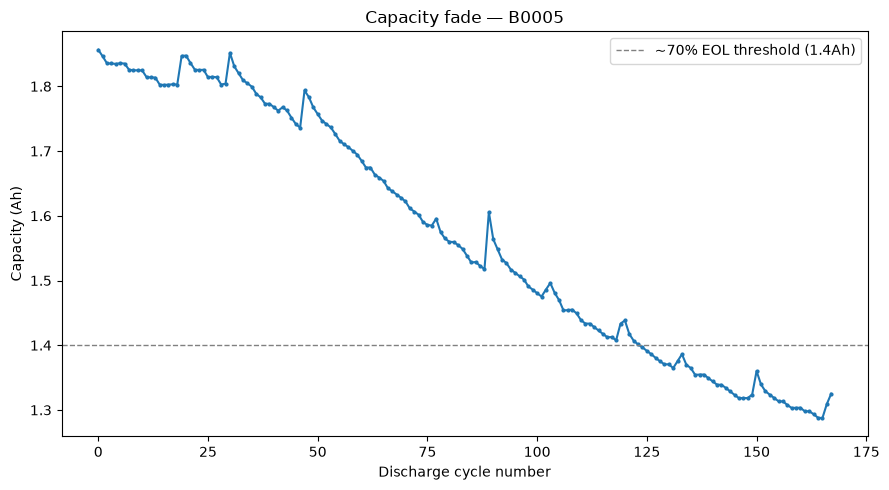

In [11]:
# Single battery capacity fade — let's look at B0005 first
single_battery = 'B0005'
sub = cycle_df[(cycle_df.battery == single_battery) & (cycle_df.type == 'discharge')].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(sub)), sub['capacity_Ah'], marker='.', markersize=4, color='tab:blue')
ax.axhline(1.4, color='gray', linestyle='--', linewidth=1, label='~70% EOL threshold (1.4Ah)')
ax.set_xlabel('Discharge cycle number')
ax.set_ylabel('Capacity (Ah)')
ax.set_title(f'Capacity fade — {single_battery}')
ax.legend()
plt.tight_layout()
plt.show()

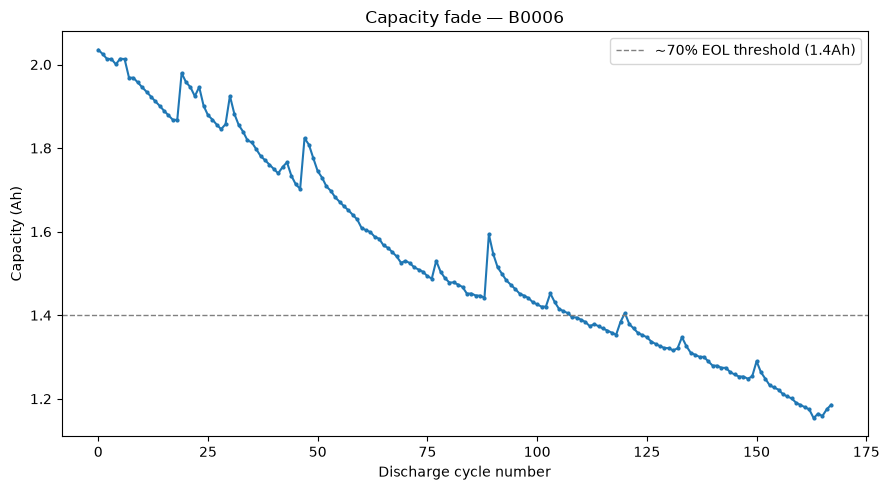

In [12]:
# Single battery capacity fade — let's look at B0006 first
single_battery = 'B0006'
sub = cycle_df[(cycle_df.battery == single_battery) & (cycle_df.type == 'discharge')].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(sub)), sub['capacity_Ah'], marker='.', markersize=4, color='tab:blue')
ax.axhline(1.4, color='gray', linestyle='--', linewidth=1, label='~70% EOL threshold (1.4Ah)')
ax.set_xlabel('Discharge cycle number')
ax.set_ylabel('Capacity (Ah)')
ax.set_title(f'Capacity fade — {single_battery}')
ax.legend()
plt.tight_layout()
plt.show()

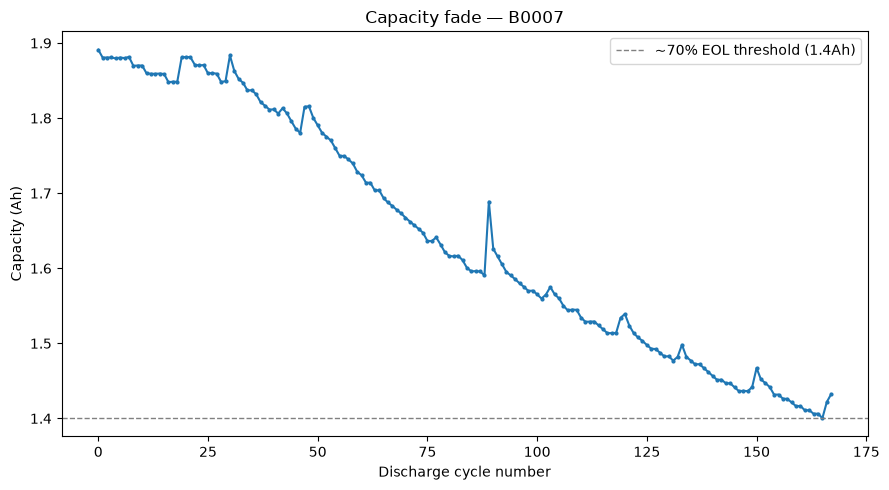

In [13]:
# Single battery capacity fade — let's look at B0007 first
single_battery = 'B0007'
sub = cycle_df[(cycle_df.battery == single_battery) & (cycle_df.type == 'discharge')].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(sub)), sub['capacity_Ah'], marker='.', markersize=4, color='tab:blue')
ax.axhline(1.4, color='gray', linestyle='--', linewidth=1, label='~70% EOL threshold (1.4Ah)')
ax.set_xlabel('Discharge cycle number')
ax.set_ylabel('Capacity (Ah)')
ax.set_title(f'Capacity fade — {single_battery}')
ax.legend()
plt.tight_layout()
plt.show()

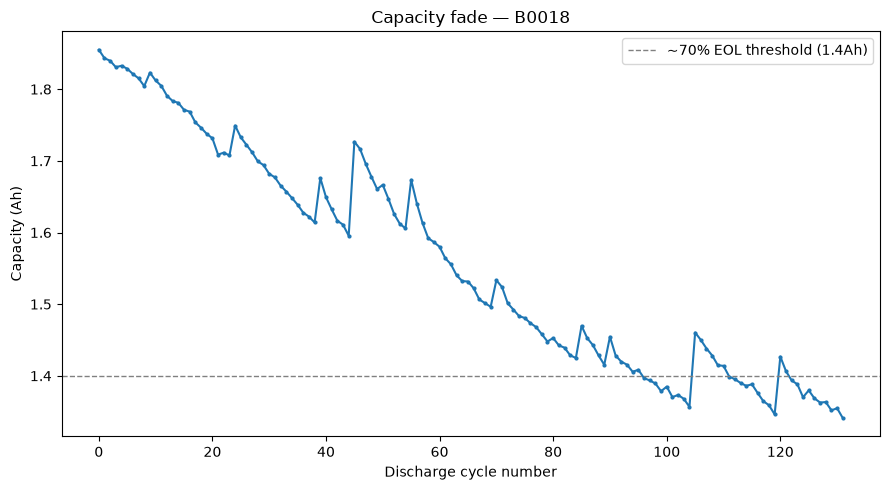

In [14]:
# Single battery capacity fade — let's look at B0018 first
single_battery = 'B0018'
sub = cycle_df[(cycle_df.battery == single_battery) & (cycle_df.type == 'discharge')].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(sub)), sub['capacity_Ah'], marker='.', markersize=4, color='tab:blue')
ax.axhline(1.4, color='gray', linestyle='--', linewidth=1, label='~70% EOL threshold (1.4Ah)')
ax.set_xlabel('Discharge cycle number')
ax.set_ylabel('Capacity (Ah)')
ax.set_title(f'Capacity fade — {single_battery}')
ax.legend()
plt.tight_layout()
plt.show()

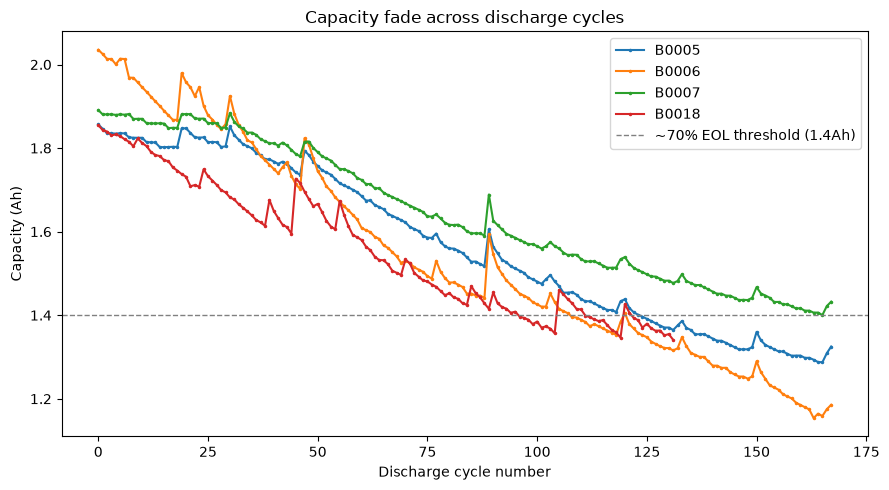

In [15]:
fig, ax = plt.subplots(figsize=(9,5))
for b in BATTERIES:
    sub = cycle_df[(cycle_df.battery==b) & (cycle_df.type=='discharge')].reset_index(drop=True)
    ax.plot(range(len(sub)), sub['capacity_Ah'], label=b, marker='.', markersize=3)
ax.axhline(1.4, color='gray', linestyle='--', linewidth=1, label='~70% EOL threshold (1.4Ah)')
ax.set_xlabel('Discharge cycle number')
ax.set_ylabel('Capacity (Ah)')
ax.set_title('Capacity fade across discharge cycles')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
cycle_df[cycle_df.type=='discharge'].groupby('battery')['capacity_Ah'].agg(['first','last','min','max','mean'])

,first,last,min,max,mean
battery,,,,,
B0005,1.856487,1.325079,1.287453,1.856487,1.572502
B0006,2.035338,1.185675,1.153818,2.035338,1.546851
B0007,1.891052,1.432455,1.400455,1.891052,1.644421
B0018,1.855005,1.341051,1.341051,1.855005,1.557701


Observation 11 (Capacity Fade): All four batteries show a clear degradation in capacity as the cycle count increases, dropping from an initial ~2.0Ah to approximately ~1.15–1.4Ah. This serves as the primary degradation signal and target variable for our analysis. There is noticeable battery-to-battery variation: B0006 shows more significant degradation (reaching a minimum of 1.15Ah), while B0007 demonstrates less degradation (minimum of 1.40Ah).

Observation 12 (Non-monotonicity): In some parts of the capacity curves, sudden dips or jumps (non-monotonic behavior) may be observed. This is likely due to the "capacity recovery effect," where the battery regains some capacity after a rest period. Depending on the modeling goal, this can either be treated as noise to be filtered or retained as-is to capture real-world battery behavior.


In [17]:
imp_rows = []
for b in BATTERIES:
    for i, c in enumerate(raw[b]):
        if c.type != 'impedance':
            continue
        d = c.data
        re = np.array(d.Re).flatten()
        rct = np.array(d.Rct).flatten()
        imp_rows.append({'battery': b, 'cycle_idx': i,
                          're_ohm': re[0] if re.size else np.nan,
                          'rct_ohm': rct[0] if rct.size else np.nan})
imp_df = pd.DataFrame(imp_rows)
imp_df.groupby('battery')[['re_ohm','rct_ohm']].agg(['min','max','mean'])

re_ohm                       rct_ohm                    
              min       max      mean       min       max      mean
battery                                                            
B0005    0.043559  0.063516  0.054245  0.064883  0.089757  0.077340
B0006    0.059131  0.079141  0.070052  0.077956  0.106684  0.093020
B0007    0.035920  0.067294  0.052807  0.060073  0.093572  0.076874
B0018    0.059112  0.066069  0.062976  0.083811  0.102295  0.089090

Observation 13 (Impedance Ranges): The electrolyte resistance (Re) and charge transfer resistance (Rct) consistently show positive values within the range of 0.03–0.11 ohms, with no anomalous negative or complex outliers. Batteries B0006 and B0018 consistently exhibit slightly higher impedance levels compared to B0005 and B0007, suggesting inherent variations in aging characteristics or batch differences.

Observation 14 (EIS Data Scarcity): Battery B0018 contains significantly fewer impedance cycles (53) compared to the others (278). This confirms that B0018 was subjected to a different test protocol with a lower frequency of Electrochemical Impedance Spectroscopy (EIS) testing, further reinforcing the conclusion that it belongs to a different batch or test run.
